In [1]:
%reset -f

In [2]:
import pypsa
import pandas as pd
import os

In [3]:
data_path = os.path.join(os.getcwd(), 'data')

In [4]:
n = pypsa.Network()

# adding buses
n.add('Bus', 'MV_bus', v_nom = 20)
n.add('Bus', 'LV_bus', v_nom = 0.4)

#adding gens
n.add('Generator', 'Grid', bus = 'MV_bus', p_nom = 100, marginal_cost = 50, control = 'Slack')

#adding loads
n.add('Load', 'industry', bus = 'LV_bus', p_set = 50)

#adding transformer
# n.add('Transformer', 'MV_LV_trafo', bus0 = 'MV_bus_2', bus1 = 'LV_bus', s_nom = 100, r = 0.01)

#adding links
# links best represent abstracted DC flows, we don't want AC power dynamics, voltage angles and so on
n.add('Link', 'single-directionalLink', bus0 = 'MV_bus', bus1 = 'LV_bus', p_nom = 100, efficiency = 0.94, )




In [5]:
n.optimize(), 
n.objective

C:\Users\rizal\AppData\Local\Temp\ipykernel_24716\3383980525.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(),
Index(['MV_bus', 'LV_bus'], dtype='object', name='name')
Index(['single-directionalLink'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2 primals, 6 duals
Objective: 2.66e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, Link-fix-p-upper were not assigned to t

2659.5744680851067

In [6]:
print(n.generators_t.p)

name           Grid
snapshot           
now       53.191489


In [7]:
n.links_t.p

name,single-directionalLink
snapshot,
now,53.191489


# Network -2


check claude, have some good stuff there!!

In [8]:
n = pypsa.Network()

n.add('Bus', 'Extern_grid', v_nom = 20)
n.add('Bus', 'Industry_1', v_nom = 0.4)
n.add('Bus', 'Residential_1', v_nom = 0.4)

n.add('Generator', 'Grid', bus = 'Extern_grid', p_nom = 100, marginal_cost = 50, control = 'Slack')
# n.add('Generator', 'Roof_pv', bus = 'Residential_1', p_nom = 1, marginal_cost = 0, control = 'PV')

n.add('Load', 'Industry', bus = 'Industry_1', p_set = 50)
n.add('Load', 'Residential', bus = 'Residential_1', p_set = 30)

n.add('Link', 'Industry', bus0 = 'Extern_grid', bus1 = 'Industry_1', p_nom = 100, efficiency = 0.94)
n.add('Link', 'Residential', bus0 = 'Extern_grid', bus1 = 'Residential_1', p_nom = 100, efficiency = 0.94)

n.optimize(),n.objective

C:\Users\rizal\AppData\Local\Temp\ipykernel_24716\3895018159.py:16: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(),n.objective
Index(['Extern_grid', 'Industry_1', 'Residential_1'], dtype='object', name='name')
Index(['Industry', 'Residential'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.02s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3 primals, 9 duals
Objective: 4.26e+03
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower, 

(('ok', 'optimal'), 4255.319148936171)

In [9]:
n = pypsa.Network()

n.set_snapshots(pd.date_range('2026-01-01 10:00:00', periods = 3, freq = 'h'))
n.add('Bus', 'Extern_grid', v_nom = 20)
n.add('Bus', 'Industry_1', v_nom = 0.4)
n.add('Bus', 'Residential_1', v_nom = 0.4)

gen_pu = pd.DataFrame({
    'Roof_pv' : [0.8, 1, 1], #Grid not included, as it is a slack gen,
    'Grid' : [1]*len(n.snapshots)
}, index = n.snapshots)
n.add('Generator', 'Grid', bus = 'Extern_grid', p_nom = 100, marginal_cost = 50, control = 'Slack')
n.add('Generator', 'Roof_pv', bus = 'Residential_1', p_nom = 1, marginal_cost = 0, control = 'PV')
n.generators_t.p_max_pu = gen_pu

loads_df = pd.DataFrame({
    'Industry' : [50, 50, 50],
    'Residential' : [30, 40, 30],
}, index = n.snapshots)

n.add('Load', 'Industry', bus = 'Industry_1', p_set = loads_df['Industry'])
n.add('Load', 'Residential', bus = 'Residential_1', p_set = loads_df['Residential'])

n.add('Link', 'Industry', bus0 = 'Extern_grid', bus1 = 'Industry_1', p_nom = 100, efficiency = 0.94)
n.add('Link', 'Residential', bus0 = 'Extern_grid', bus1 = 'Residential_1', p_nom = 100, efficiency = 0.94)

n.optimize(),n.objective

C:\Users\rizal\AppData\Local\Temp\ipykernel_24716\3840649645.py:27: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(),n.objective
Index(['Extern_grid', 'Industry_1', 'Residential_1'], dtype='object', name='name')
Index(['Industry', 'Residential'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.03s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 12 primals, 33 duals
Objective: 1.31e+04
Solver: highs
Runtime: 0.00s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p-lower

(('ok', 'optimal'), 13148.936170212768)

In [10]:
n.loads_t.p_set.sum(axis = 1)

snapshot
2026-01-01 10:00:00    80.0
2026-01-01 11:00:00    90.0
2026-01-01 12:00:00    80.0
Freq: h, dtype: float64

In [11]:
n.generators_t.p_max_pu

,Roof_pv,Grid
snapshot,,
2026-01-01 10:00:00,0.8,1
2026-01-01 11:00:00,1.0,1
2026-01-01 12:00:00,1.0,1


# Network -3


In [35]:
#Importing network data from excel files; consider moving to csv's

buses_df = pd.read_excel(os.path.join(data_path, 'buses.xlsx'), index_col = 0)
buses_df = buses_df.drop(['MV_bus_2'] ) #dropping the second MV bus, will add back when dealing with switching behaviour

gens_df = pd.read_excel(os.path.join(data_path, 'gens.xlsx'), index_col = 0)

links_df = pd.read_excel(os.path.join(data_path, 'links.xlsx'), index_col = 0)

loads_df = pd.read_excel(os.path.join(data_path, 'loads.xlsx'), index_col = 0)


In [36]:
gens_df.loc['Roof_pv', 'control'] = 'PV'
gens_df.loc['Roof_pv', 'marginal_cost'] = 10
gens_df

,bus,control,p_nom,carrier,marginal_cost
name,,,,,
Roof_pv,Residential_1,PV,1,solar,10
Grid,Extern_grid,Slack,100000,grid,50


In [37]:
buses_df

,v_nom,x,y,carrier
name,,,,
Industry_1,0.4,7.939685,48.466652,DC
Kritis_1,0.4,7.940721,48.464698,DC
Residential_1,0.4,7.941092,48.466760,DC
Extern_grid,110.0,7.941827,48.467811,DC
MV_bus_1,20.0,7.937179,48.466180,DC


In [38]:
# Adding thermal buses at same locations as electrical buses, to represent thermal energy flows.
thermal_buses_df = buses_df.copy(deep = True)
thermal_buses_df.index = thermal_buses_df.index + '_thermal'
thermal_buses_df['carrier'] = 'thermal'
thermal_buses_df = thermal_buses_df.drop(columns = ['v_nom'])
thermal_buses_df = thermal_buses_df.drop(index = ['Extern_grid_thermal'])
thermal_buses_df

,x,y,carrier
name,,,
Industry_1_thermal,7.939685,48.466652,thermal
Kritis_1_thermal,7.940721,48.464698,thermal
Residential_1_thermal,7.941092,48.466760,thermal
MV_bus_1_thermal,7.937179,48.466180,thermal


Pypsa resolves carriers by carrier of buses, carriers on gens and loads, are just for grouping and statistics, and don't mean much.  
What matters is what is connected to which bus!!

In [39]:
# adding gas buses at same locations as electrical buses, to represent gas energy flows.
gas_buses_df = buses_df.copy(deep = True)
 
gas_buses_df.index = gas_buses_df.index + '_gas'
gas_buses_df.index = gas_buses_df.index.str.replace('Extern_grid_gas', 'Gas_substation')
gas_buses_df.loc['Gas_substation', 'x'] = gas_buses_df.loc['Gas_substation', 'x'] - 0.01 #jsut offsetting it a bit, might be usefule later while visualizing
gas_buses_df['carrier'] = 'gas'
gas_buses_df = gas_buses_df.drop(columns = ['v_nom'])
gas_buses_df

,x,y,carrier
name,,,
Industry_1_gas,7.939685,48.466652,gas
Kritis_1_gas,7.940721,48.464698,gas
Residential_1_gas,7.941092,48.466760,gas
Gas_substation,7.931827,48.467811,gas
MV_bus_1_gas,7.937179,48.466180,gas


In [40]:
gens_df

,bus,control,p_nom,carrier,marginal_cost
name,,,,,
Roof_pv,Residential_1,PV,1,solar,10
Grid,Extern_grid,Slack,100000,grid,50


In [41]:
links_df

,bus0,bus1,efficiency,p_nom
name,,,,
grid,Extern_grid,MV_bus_1,0.94,100
Industry,MV_bus_1,Industry_1,0.95,50
Kritis,MV_bus_1,Kritis_1,0.95,50
Residential,MV_bus_1,Residential_1,0.95,30


In [42]:
#adding gas supply station as a generator
gens_df.loc['Gas'] = {
    'bus': 'Gas_substation',
    'control' : 'Slack',
    'carrier' : 'gas',
    'p_nom' : 100, # MW
    'marginal_cost' : 20
}

# adding links to connect gas supply station to buses
links_df.loc['Gas_to_Industry'] = {
    'bus0' : 'Gas_substation',
    'bus1' : 'Industry_1_gas',
    'p_nom' : 100,
    'efficiency' : 0.99
}
links_df.loc['Gas_to_kritis'] = {**links_df.loc['Gas_to_Industry'], 'bus1' : 'Kritis_1_gas'}
links_df.loc['Gas_to_Residential'] = {**links_df.loc['Gas_to_Industry'], 'bus1' : 'Residential_1_gas'}

#adding boiler at industry bus
links_df.loc['Industry_boiler'] = {
    'bus0': 'Industry_1_gas',
    'bus1': 'Industry_1_thermal',
    'p_nom' : 0.5, #MW
    'efficiency' : 0.9
}

#adding a thermal load at industry bus
loads_df.loc['industry_thermal'] = {
    'bus' : 'Industry_1_thermal'
}



In [51]:
n = pypsa.Network()

n.set_snapshots(pd.date_range('2026-01-01 10:00:00', '2026-01-01 12:00:00', freq = 'h'))
# adding buses
n.add('Bus', buses_df.index, v_nom = buses_df['v_nom'], x = buses_df['x'], y = buses_df['y'], )
n.add('Bus', thermal_buses_df.index, x = thermal_buses_df['x'], y = thermal_buses_df['y'], carrier = thermal_buses_df['carrier'])
n.add('Bus', gas_buses_df.index, x = gas_buses_df['x'], y = gas_buses_df['y'], carrier = gas_buses_df['carrier'])

#adding gens
gen_pu = pd.DataFrame({
    'Roof_pv' : [0.8, 1, 1.2], #Grid not included, as it is a slack gen
    'Grid' : [1]*len(n.snapshots),
    'Gas_substation' : [1]*len(n.snapshots)
}, index = n.snapshots)
n.add('Generator', gens_df.index, bus = gens_df['bus'], p_nom = gens_df['p_nom'], marginal_cost = gens_df['marginal_cost'], control = gens_df['control'])
n.generators_t.p_max_pu = gen_pu

#adding loads
loads_pu = pd.DataFrame({
    'industry' : [0.8, 0.9, 1],
    'kritis' : [0.5, 0.6, 0.7],
    'residential' : [0.3, 0.4, 0.5],
    'industry_thermal' : [0.5, 0.6, 0.7]
}, index = n.snapshots)
loads_p = pd.Series({
    'industry': 45,
    'kritis': 20,
    'residential': 30,
    'industry_thermal': 0.4
})
loads_pset = loads_pu.multiply(loads_p, axis=1)
n.add('Load', loads_df.index, bus = loads_df['bus'], p_set = loads_pset)

#adding links
# links best represent abstracted DC flows, we don't want AC power dynamics, voltage angles and so on
n.add('Link', links_df.index, bus0 = links_df['bus0'], bus1 = links_df['bus1'], p_nom = links_df['p_nom'], efficiency = links_df['efficiency'])


# adding slack gens in each bus to represent load shedding
for bus in buses_df.index:
    n.add('Generator', f'Slack_{bus}', bus = bus, p_nom = 100, marginal_cost = 10000, control = 'Slack')

In [56]:

n.generators

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_nom_set,p_min_pu,...,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,weight,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Roof_pv,Residential_1,PV,,1.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,1.0
Grid,Extern_grid,Slack,,100000.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100000.0
Gas,Gas_substation,Slack,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0
Slack_Industry_1,Industry_1,Slack,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0
Slack_Kritis_1,Kritis_1,Slack,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0
Slack_Residential_1,Residential_1,Slack,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0
Slack_Extern_grid,Extern_grid,PV,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0
Slack_MV_bus_1,MV_bus_1,Slack,,100.0,0.0,False,0.0,inf,NaN,0.0,...,0,0,1,0,NaN,NaN,NaN,NaN,1.0,100.0


In [53]:
n.buses

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Industry_1,0.4,,7.939685,48.466652,AC,,,1.0,0.0,inf,PQ,,
Kritis_1,0.4,,7.940721,48.464698,AC,,,1.0,0.0,inf,PQ,,
Residential_1,0.4,,7.941092,48.466760,AC,,,1.0,0.0,inf,PQ,,
Extern_grid,110.0,,7.941827,48.467811,AC,,,1.0,0.0,inf,PQ,,
MV_bus_1,20.0,,7.937179,48.466180,AC,,,1.0,0.0,inf,PQ,,
Industry_1_thermal,1.0,,7.939685,48.466652,thermal,,,1.0,0.0,inf,PQ,,
Kritis_1_thermal,1.0,,7.940721,48.464698,thermal,,,1.0,0.0,inf,PQ,,
Residential_1_thermal,1.0,,7.941092,48.466760,thermal,,,1.0,0.0,inf,PQ,,
MV_bus_1_thermal,1.0,,7.937179,48.466180,thermal,,,1.0,0.0,inf,PQ,,


In [54]:
n.optimize(), n.objective

C:\Users\rizal\AppData\Local\Temp\ipykernel_24716\1191575196.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(), n.objective
Index(['Industry_1', 'Kritis_1', 'Residential_1', 'Extern_grid', 'MV_bus_1',
       'Industry_1_thermal', 'Kritis_1_thermal', 'Residential_1_thermal',
       'MV_bus_1_thermal', 'Industry_1_gas', 'Kritis_1_gas',
       'Residential_1_gas', 'Gas_substation', 'MV_bus_1_gas'],
      dtype='object', name='name')
Index(['Gas_substation'], dtype='str')
Index(['grid', 'Industry', 'Kritis', 'Residential', 'Gas_to_Industry',
       'Gas_to_kritis', 'Gas_to_Residential', 'Industry_boiler'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.05s
INFO:linopy.

(('ok', 'optimal'), 10712.45500921873)

In [55]:
n.generators_t.p

name,Roof_pv,Grid,Gas,Slack_Industry_1,Slack_Kritis_1,Slack_Residential_1,Slack_Extern_grid,Slack_MV_bus_1
snapshot,,,,,,,,
2026-01-01 10:00:00,0.8,60.694289,0.224467,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 11:00:00,1.0,71.108623,0.269360,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 12:00:00,1.2,81.522956,0.314254,-0.0,-0.0,-0.0,-0.0,-0.0


## Visualization

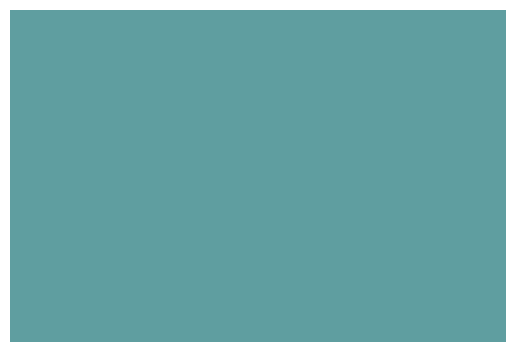

In [ ]:
import matplotlib.pyplot as plt
n.plot(geomap = True)
plt.show()

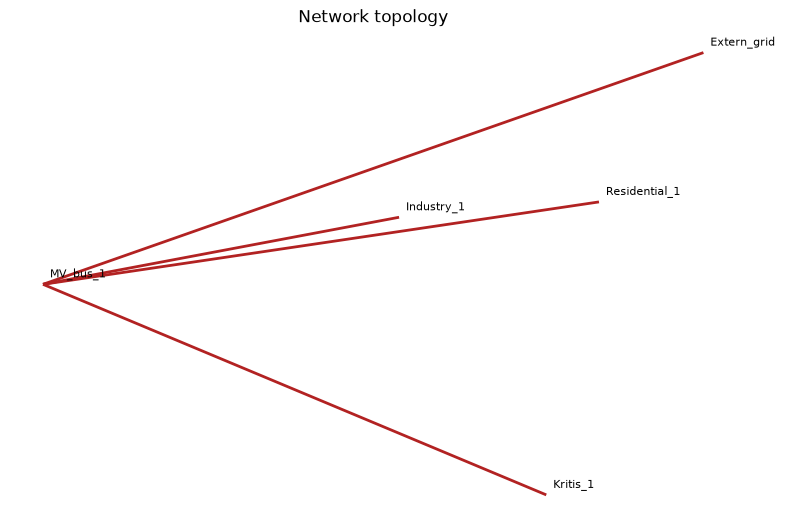

In [ ]:

import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8, 8))

n.plot(
    ax=ax,
    geomap=False,          # <-- key fix: don't require cartopy GeoAxes
    bus_sizes=0.0000000000002,
    bus_colors="steelblue",
    line_widths=0,
    link_widths=2,
    link_colors="firebrick",
    title="Network topology",
)

# add bus name annotations
for name, row in n.buses.iterrows():
    ax.annotate(
        name,
        xy=(row.x, row.y),
        xytext=(5, 5),                # offset in points, so it doesn't sit on top of the marker
        textcoords="offset points",
        fontsize=8,
        ha="left",
    )

plt.tight_layout()
plt.show()

ValueError: Colors not defined for all elements in the second MultiIndex 

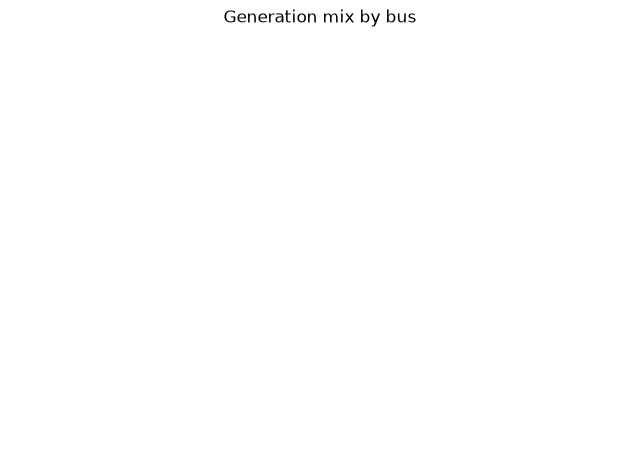

In [ ]:
gen_by_bus_carrier = n.generators.groupby(["bus", "carrier"]).p_nom.sum()

# 2. Plot
fig, ax = plt.subplots(figsize=(8, 8))

n.plot(
    ax=ax,
    geomap=False,
    bus_sizes=gen_by_bus_carrier / gen_by_bus_carrier.max() * 0.0005,  # scale to your coord range
    line_widths=0,
    link_widths=2,
    link_colors="grey",
    title="Generation mix by bus",
)

plt.tight_layout()
plt.show()

In [ ]:
n.carriers

attribute,co2_emissions,color,nice_name,max_growth,max_relative_growth
name,,,,,


In [ ]:
print(n.buses)

               v_nom type         x          y carrier unit location  \
name                                                                   
Industry_1       0.4       7.939685  48.466652      AC                 
Kritis_1         0.4       7.940721  48.464698      AC                 
Residential_1    0.4       7.941092  48.466760      AC                 
Extern_grid    110.0       7.941827  48.467811      AC                 
MV_bus_1        20.0       7.937179  48.466180      AC                 

               v_mag_pu_set  v_mag_pu_min  v_mag_pu_max control  \
name                                                              
Industry_1              1.0           0.0           inf   Slack   
Kritis_1                1.0           0.0           inf   Slack   
Residential_1           1.0           0.0           inf   Slack   
Extern_grid             1.0           0.0           inf   Slack   
MV_bus_1                1.0           0.0           inf   Slack   

                         

<Axes: xlabel='component,carrier,bus_carrier'>

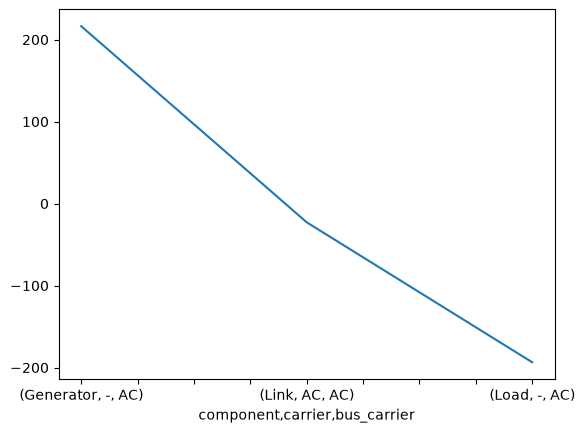

In [ ]:
n.stats.energy_balance().plot()

In [ ]:
import linopy

m = linopy.Model()

x = m.add_variables(lower=0, name="x")

m.add_constraints(x >= 5)

m.add_objective(x)

m.solve(solver_name = 'highs')

print(x.solution)

INFO:linopy.model: Solve problem using Highs solver


INFO:linopy.io: Writing time: 0.08s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 1 primals, 1 duals
Objective: 5.00e+00
Solver model: available
Solver message: Optimal



<xarray.DataArray 'solution' ()> Size: 8B
array(5.)
